In [20]:
import torch
import torch.nn as nn
import lightning.pytorch as pl
from lightning.pytorch import loggers as pl_loggers
from lightning.pytorch.callbacks import LearningRateMonitor
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np

from models.vqvae import VQVAE
from models.vqvae_2 import VQVAE2
from models.resnet import ResNet

In [25]:
class LatentDataset(torch.utils.data.Dataset):
    def __init__(self, path: str):
        super(LatentDataset, self).__init__()

        self.path = path

        self.data = np.load(self.path)

    def __len__(self):
        return self.data.shape[0] - 1

    def __getitem__(self, idx):
        
        item_1 = self.data[idx]
        item_2 = self.data[idx + 1]

        return item_1, item_2

In [26]:
class LatentNetwork(pl.LightningModule):
    def __init__(self, in_channels: int, lr: float, vqvae: VQVAE):
        super(LatentNetwork, self).__init__()

        self.save_hyperparameters()

        self.lr = lr
        self.example_input_array = torch.rand(1, 4, 16, 8)

        self.vqvae = vqvae
        self.quantize_loss_weight = 0.1

        self.vqvae.freeze()
        self.vqvae.eval()

        self.in_channels = in_channels

        self.network = nn.Sequential(
            nn.Conv2d(in_channels=self.in_channels, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=self.in_channels, kernel_size=3, padding=1),
        )

        # self.network = ResNet(in_channels=8)

    def forward(self, x):

        out = self.network(x)

        return out
    
    def training_step(self, batch, batch_idx):
        x_1, x_2 = batch

        pred = self(x_1)
        pred_quantized, quantize_loss_1, _ = self.vqvae.quantize(pred)

        prediction_loss = torch.nn.functional.mse_loss(pred_quantized, x_2)
        commitment_loss = quantize_loss_1["commitment_loss"]

        loss = prediction_loss + self.quantize_loss_weight * commitment_loss

        self.log('train_loss', loss, prog_bar=True)

        return loss

    def validation_step(self, batch, batch_idx):
        x_1, x_2 = batch

        pred = self(x_1)
        pred_quantized, quantize_loss_1, _ = self.vqvae.quantize(pred)

        prediction_loss = torch.nn.functional.mse_loss(pred_quantized, x_2)
        commitment_loss = quantize_loss_1["commitment_loss"]

        loss = prediction_loss + self.quantize_loss_weight * commitment_loss

        self.log('val_loss', loss)

        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr)
        lr_scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, verbose=True)

        return {"optimizer": optimizer, "lr_scheduler": {"scheduler": lr_scheduler, "monitor": "val_loss"}}

In [27]:
# Hyperparameters
batch_size = 1024
lr = 4e-3

# Dataset
train_dataset = LatentDataset("latent_train.npy")
val_dataset = LatentDataset("latent_val.npy")

# DataLoader
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# Model
checkpoint_vqvae = "logs/vqvae_dim4_c8192/version_0/checkpoints/epoch=11-step=27612.ckpt"
# vqvae = VQVAE.load_from_checkpoint(checkpoint_vqvae, in_channels=5)
vqvae = VQVAE2.load_from_checkpoint(checkpoint_vqvae)

model = LatentNetwork(in_channels=4, lr=lr, vqvae=vqvae)
# model = LatentNetwork.load_from_checkpoint("logs/forecastnet/version_12/checkpoints/epoch=39-step=2880.ckpt", lr=1e-5, vqvae=vqvae)

In [ ]:
def train():

    tb_logger = pl_loggers.TensorBoardLogger(
        save_dir="logs/", name="forecastnet_full_ds_with_lr_scheduler")
    
    lr_monitor = LearningRateMonitor(logging_interval='step')

    trainer = pl.Trainer(
        logger=tb_logger,
        max_epochs=-1,
        callbacks=[lr_monitor],
    )

    trainer.fit(
        model=model,
        train_dataloaders=train_loader,
        val_dataloaders=val_loader
    )

train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name    | Type       | Params | Mode  | In sizes      | Out sizes    
-------------------------------------------------------------------------------
0 | vqvae   | VQVAE2     | 5.5 M  | eval  | ?             | ?            
1 | network | Sequential | 115 K  | train | [1, 4, 16, 8] | [1, 4, 16, 8]
-------------------------------------------------------------------------------
115 K     Trainable params
5.5 M     Non-trainable params
5.7 M     Total params
22.616    Total estimated model params size (MB)
10        Modules in train mode
204       Modules in eval mode


Epoch 76:  24%|██▎       | 17/72 [00:01<00:05, 10.10it/s, v_num=0, train_loss=0.555]


Detected KeyboardInterrupt, attempting graceful shutdown ...


NameError: name 'exit' is not defined

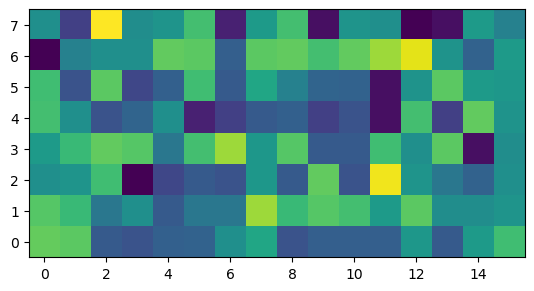

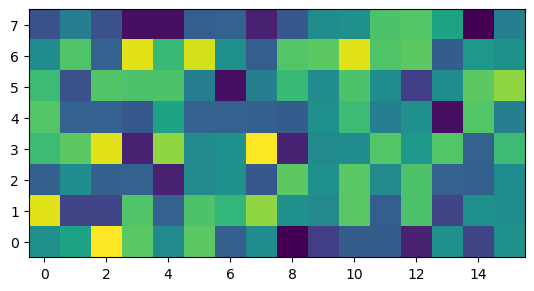

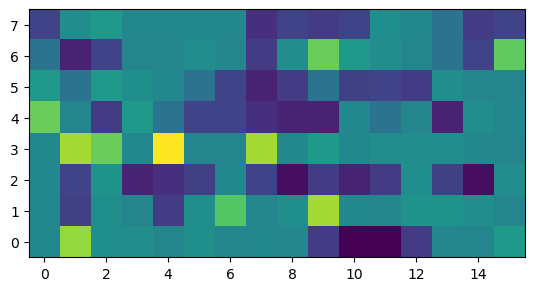

0.4930904


In [53]:
model = LatentNetwork.load_from_checkpoint("logs/forecastnet_direct_48h/version_1/checkpoints/epoch=39-step=2880.ckpt", lr=1e-3, vqvae=vqvae).cpu()
model.eval()

sample_x, sample_y = train_dataset[0]

pred = model(torch.tensor(sample_x).unsqueeze(0).float())
pred, _, _ = model.vqvae.quantize(pred)

pred = pred.detach().numpy().squeeze()

from matplotlib import pyplot as plt

plt.imshow(sample_x[0].T, origin='lower')
plt.show()

plt.imshow(sample_y[0].T, origin='lower')
plt.show()

plt.imshow(pred[0].T, origin='lower')
plt.show()

mse = np.mean((sample_y - pred) ** 2)
print(mse)